In [22]:
import xarray as xr
import dask
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from os.path import join



In [2]:
from dask.distributed import LocalCluster, Client

cluster = LocalCluster()
client = Client(cluster)
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/dkimpara/pux/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/dkimpara/pux/proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43917,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/dkimpara/pux/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38087,Total threads: 1
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/dkimpara/pux/proxy/32935/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:37655,


In [11]:
data_stats = xr.open_dataset("/glade/derecho/scratch/dkimpara/goes-cloud-dataset/data_stats.nc")
data_stats["channel"] = [4, 7,8,9,10, 13] 

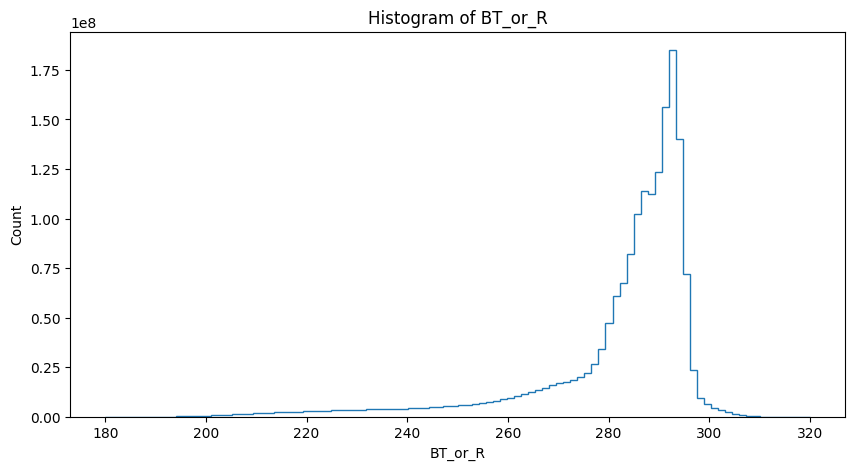

In [24]:
# Open the zarr store — chunks are already defined, Dask handles lazily
ds = xr.open_zarr('/glade/derecho/scratch/dkimpara/goes-cloud-dataset/goes_10km_2025.zarr')

ds = ds.sel(t=slice(pd.Timestamp("2025-06-13T00:00:00"), pd.Timestamp("2025-07-10T00:00:00")))
ds = ds.sel(latitude=slice(-24, 24.1))

# Compute histogram lazily using dask.array directly (much faster than .values)
data = ds['BT_or_R'].sel(channel=13).data.ravel()  # dask array, still lazy

# Option A: numpy histogram via dask (recommended)
hist, edges = dask.array.histogram(data, bins=100, range=(180, 320))
hist, edges = dask.compute(hist, edges)  # triggers computation

plt.figure(figsize=(10, 5))
plt.stairs(hist, edges)
plt.xlabel('BT_or_R')
plt.ylabel('Count')
plt.title('Histogram of BT_or_R')
plt.savefig('histogram.png', dpi=150)

In [25]:
save_file = join("/glade/derecho/scratch/dkimpara/goes_10km_train/baselines",
                "hist_edges.npy")
with open(save_file, 'wb') as f:
    np.save(f, edges)

save_file = join("/glade/derecho/scratch/dkimpara/goes_10km_train/baselines",
                "hist_tropics.npy")
with open(save_file, 'wb') as f:
    np.save(f, hist)

